# Logistic regression: PyTorch first, then scratch implementations and numerical stability

**First make a classifier work. Then open up the functions it uses.**

1. Start with small tensors and PyTorch's **autograd**. Train and visualize binary and
   multiclass logistic regression using `nn.Linear` and built-in losses.
2. Implement the **forward calculations** ourselves: sigmoid, softmax, and cross-entropy.
   PyTorch still computes every gradient through `.backward()`.
3. Try extreme inputs, see the failures, and build better numerical routines.
   Connect these back to the logits-based losses used in the first part.

We do **not** implement backpropagation or calculate parameter gradients by hand.
“From scratch” here means writing the model's forward arithmetic and losses using tensor operations.

This follows **L1's likelihood view** and **L5B's numerical stability examples**:
softplus at 1000 and softmax of (1000, 999, 998).
[L5B lecture](https://nipunbatra.github.io/dl-teaching/slides-pdf/L5B.pdf).
Class indices start at **0** throughout.

**Colab:** upload this `.ipynb` at [Google Colab](https://colab.research.google.com/),
choose a CPU runtime, then **Runtime → Run all**. No data downloads or repository files
are needed. PyTorch and Matplotlib are available in Colab. Plots use **retina** output.

**Teaching route:** PyTorch and autograd (sections 1–5), scratch forward functions (6),
numerical failures and repairs (7–10), then connections and exercises (11–13).
Pause at the prediction questions. Prerequisites: dot products and the idea of gradient descent.

In [1]:
%config InlineBackend.figure_format = 'retina'

import math
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# float32 makes the lecture's finite-precision failures visible.
torch.set_default_dtype(torch.float32)
torch.manual_seed(7)
torch.set_num_threads(2)  # small CPU examples do not need many threads
torch.set_printoptions(precision=5, sci_mode=False)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
COLORS = ["#2f6fbb", "#e07824", "#238b8e"]
print("PyTorch:", torch.__version__, "| dtype:", torch.get_default_dtype())

PyTorch: 2.14.0 | dtype: torch.float32


## 1. Let PyTorch calculate a derivative

Start with three scalar tensors. `requires_grad=True` asks PyTorch to track operations
involving a parameter. We write the forward calculation, then call `.backward()` on its loss.
PyTorch stores each parameter's derivative in `.grad`.

This first example is just a squared-error warm-up: $z=wx+b$, $L=(z-10)^2$.
It is not yet a classification model.

In [2]:
x_warmup = torch.tensor(3.0)
w_warmup = torch.tensor(2.0, requires_grad=True)
b_warmup = torch.tensor(1.0, requires_grad=True)

z_warmup = w_warmup * x_warmup + b_warmup
loss_warmup = (z_warmup - 10.0) ** 2
loss_warmup.backward()  # PyTorch differentiates the whole forward calculation

print("prediction:", z_warmup.item(), "| loss:", loss_warmup.item())
print("w.grad:", w_warmup.grad.item(), "| b.grad:", b_warmup.grad.item())

with torch.no_grad():
    w_warmup -= 0.01 * w_warmup.grad
    b_warmup -= 0.01 * b_warmup.grad
    new_loss = (w_warmup * x_warmup + b_warmup - 10.0) ** 2
print("loss after one update:", new_loss.item())
assert new_loss < loss_warmup

prediction: 7.0 | loss: 9.0
w.grad: -18.0 | b.grad: -6.0
loss after one update: 5.760000228881836


The derivatives tell us how to change the parameters. Gradient descent subtracts a small
multiple of them. `torch.no_grad()` keeps this update out of the next computation graph.

PyTorch **accumulates** gradients, so a training loop must clear old gradients each step.
Soon `optimizer.zero_grad()` and `optimizer.step()` will handle these two jobs for us.

## 2. Binary classification with PyTorch

With two features, the model has just **three learned numbers**: $w_1,w_2,b$.

$$z=w_1x_1+w_2x_2+b,\qquad p=P(y=1\mid x)=\sigma(z)=\frac{1}{1+e^{-z}}.$$

$z$ is the **logit**, a real-valued score. It is the log-odds:
$z=\log[p/(1-p)]$. Positive logits favor class 1; negative logits favor class 0.
The model is called *logistic regression*, but here it solves a classification problem.

**Predict:** for $x=(2,-1), w=(0.5,-0.5), b=-0.5$, what are $z$ and $p$?

z = 1.0000, P(y=1) = 0.7311, P(y=0) = 0.2689


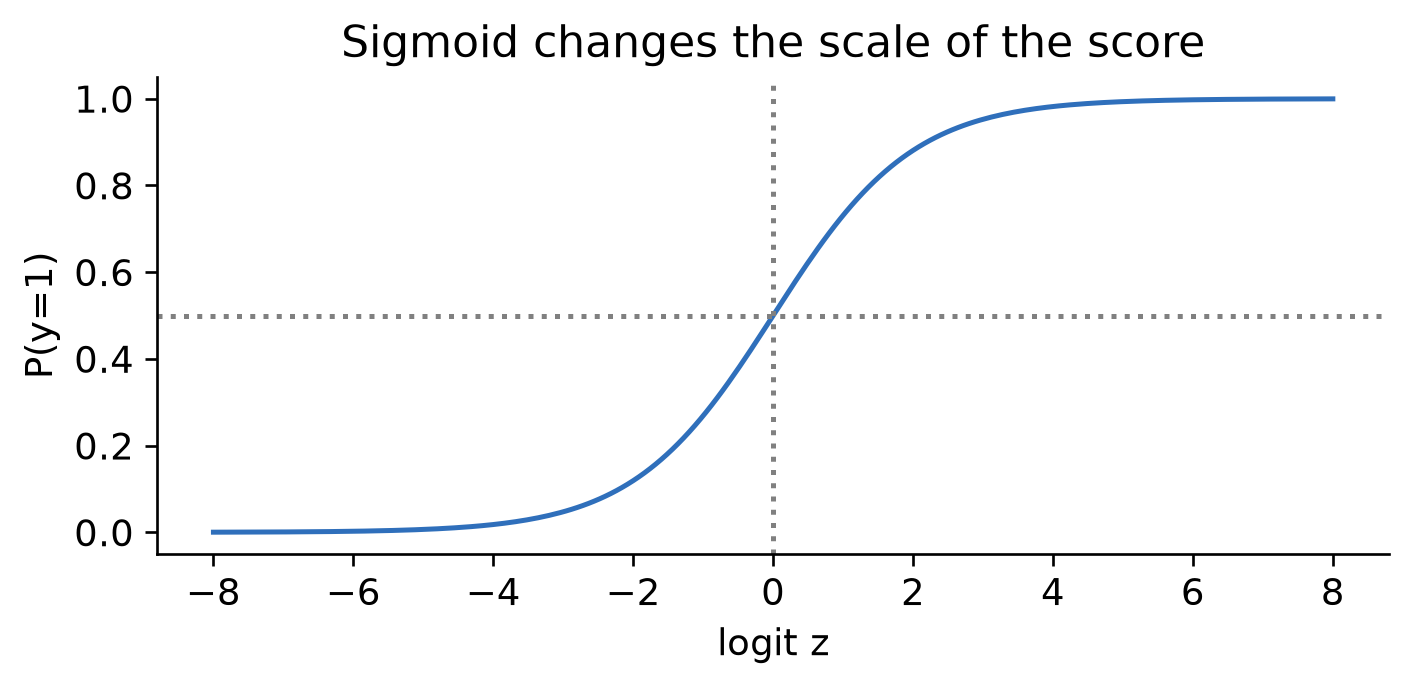

In [3]:
x = torch.tensor([2.0, -1.0])
w_example = torch.tensor([0.5, -0.5])
b_example = torch.tensor(-0.5)
z = x @ w_example + b_example
p = torch.sigmoid(z)
print(f"z = {z.item():.4f}, P(y=1) = {p.item():.4f}, P(y=0) = {(1-p).item():.4f}")

scores = torch.linspace(-8, 8, 201)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(scores, torch.sigmoid(scores), color=COLORS[0])
ax.axhline(0.5, color="gray", linestyle=":")
ax.axvline(0, color="gray", linestyle=":")
ax.set(xlabel="logit z", ylabel="P(y=1)", title="Sigmoid changes the scale of the score")
plt.tight_layout()
plt.show()

### The Bernoulli likelihood gives binary cross-entropy

For one observed label, $P(y\mid x)=p^y(1-p)^{1-y}$.
Taking the negative natural logarithm gives

$$\ell=-y\log p-(1-y)\log(1-p).$$

For $y=1$, the loss is $-\log p$; for $y=0$, it is $-\log(1-p)$.
Minimizing the **mean** loss maximizes the conditional likelihood of the training labels
under the usual independent-observation assumption.
At $p=0.5$ the loss is $\log 2\approx0.693$, regardless of the label.

**Predict:** if the true label is 0, is our $p\approx0.731$ a good prediction?

For now, let PyTorch calculate this loss using `binary_cross_entropy_with_logits(z, y)`.
It accepts the score $z$, before sigmoid. We use sigmoid separately to read the probability.
Later we will implement the formula ourselves and discover why the built-in loss takes logits.

In [4]:
for label in [0.0, 1.0]:
    loss = F.binary_cross_entropy_with_logits(z, torch.tensor(label))
    print(f"y={label:.0f}, p={p.item():.4f}, loss={loss.item():.4f}")

y=0, p=0.7311, loss=1.3133
y=1, p=0.7311, loss=0.3133


### One classification update using autograd

Set the true label to 0. Our probability of class 1 is about 0.731, so it should decrease.
We write the score and loss, call `.backward()`, and inspect the gradients PyTorch gives us.
There is no derivative formula to implement.

In [5]:
w_one = w_example.clone().requires_grad_()
b_one = b_example.clone().requires_grad_()
target_one = torch.tensor(0.0)
z_one = x @ w_one + b_one
p_one = torch.sigmoid(z_one)
loss_one = F.binary_cross_entropy_with_logits(z_one, target_one)
loss_one.backward()
print("dw =", w_one.grad, "| db =", b_one.grad)

with torch.no_grad():  # parameter updates are not part of the next gradient graph
    w_one -= 0.1 * w_one.grad
    b_one -= 0.1 * b_one.grad
    z_after = x @ w_one + b_one
    p_after = torch.sigmoid(z_after)
    loss_after = F.binary_cross_entropy_with_logits(z_after, target_one)
print(f"p: {p_one.item():.4f} -> {p_after.item():.4f}")
print(f"loss: {loss_one.item():.4f} -> {loss_after.item():.4f}")
assert loss_after < loss_one

dw = tensor([ 1.46212, -0.73106]) | db = tensor(0.73106)
p: 0.7311 -> 0.6368
loss: 1.3133 -> 1.0127


## 3. Train a complete binary classifier

Each row of $X$ describes one observation with two numerical features.
The target is $y=0$ or $y=1$. We generate overlapping clouds so that a straight line
helps, but perfect accuracy is not expected. These are synthetic classes, not real measurements.

We shuffle and split **before** computing feature means and standard deviations.
The test set remains unseen during training. Scaling uses training statistics only.

X: torch.Size([270, 2]) torch.float32 | y: torch.Size([270]) torch.float32


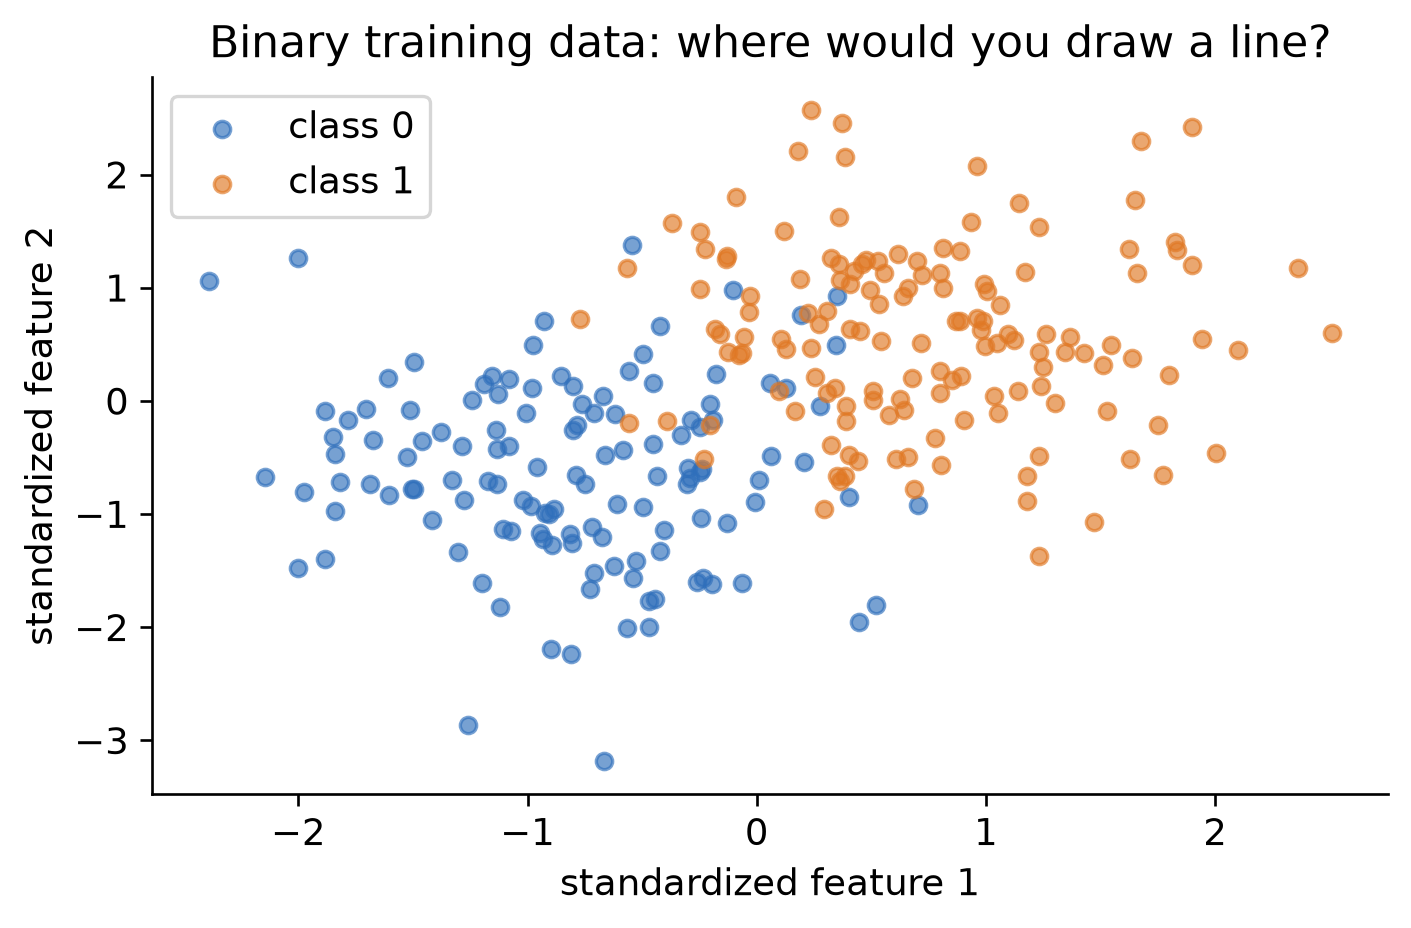

In [6]:
g_binary = torch.Generator().manual_seed(12)
X_binary = torch.cat([
    torch.randn(180, 2, generator=g_binary) + torch.tensor([-1.2, -0.7]),
    torch.randn(180, 2, generator=g_binary) + torch.tensor([1.2, 0.7]),
])
y_binary = torch.cat([torch.zeros(180), torch.ones(180)])
order = torch.randperm(len(X_binary), generator=g_binary)
train_idx, test_idx = order[:270], order[270:]
mean_b = X_binary[train_idx].mean(dim=0)
std_b = X_binary[train_idx].std(dim=0)
Xb_train = (X_binary[train_idx] - mean_b) / std_b
Xb_test = (X_binary[test_idx] - mean_b) / std_b
yb_train, yb_test = y_binary[train_idx], y_binary[test_idx]
print("X:", Xb_train.shape, Xb_train.dtype, "| y:", yb_train.shape, yb_train.dtype)

fig, ax = plt.subplots(figsize=(6, 4))
for k in range(2):
    points = Xb_train[yb_train == k]
    ax.scatter(points[:, 0], points[:, 1], s=24, alpha=0.65,
               color=COLORS[k], label=f"class {k}")
ax.set(xlabel="standardized feature 1", ylabel="standardized feature 2",
       title="Binary training data: where would you draw a line?")
ax.legend()
plt.tight_layout()
plt.show()

### The entire training loop in standard PyTorch

`nn.Linear(2, 1)` stores two weights and one bias and computes $z=Xw+b$.
It returns shape `[N, 1]`; `.squeeze(-1)` gives `[N]` to match our floating-point targets.
`BCEWithLogitsLoss` calculates the mean binary loss directly from those logits.

Read the loop line by line: **clear gradients → forward pass → loss → backward → update**.
`SGD.step()` performs the parameter update using the gradients from `.backward()`.
This is full-batch gradient descent: every step uses all training rows.

The model has no sigmoid layer. We use sigmoid when displaying probabilities.

In [7]:
learning_rate = 0.2
steps = 250
binary_history = []

binary_model = torch.nn.Linear(2, 1)
with torch.no_grad():
    binary_model.weight.zero_()
    binary_model.bias.zero_()
binary_criterion = torch.nn.BCEWithLogitsLoss()
binary_optimizer = torch.optim.SGD(binary_model.parameters(), lr=learning_rate)

for step in range(steps):
    binary_optimizer.zero_grad()
    logits = binary_model(Xb_train).squeeze(-1)
    loss = binary_criterion(logits, yb_train)
    loss.backward()
    binary_optimizer.step()
    binary_history.append(loss.item())
    if step in [0, 49, 99, 249]:
        print(f"step {step:3d} | training BCE {loss.item():.4f}")

step   0 | training BCE 0.6931
step  49 | training BCE 0.2507
step  99 | training BCE 0.2108
step 249 | training BCE 0.1841


### Evaluate on unseen examples and inspect the decision boundary

For a 0.5 probability threshold, $p\geq0.5$ is equivalent to $z\geq0$.
We need sigmoid for probabilities, but can predict the class **directly from the logit**.
The boundary is the line $w_1x_1+w_2x_2+b=0$.
Accuracy counts correct labels; loss also measures how much probability was assigned to them.
We report the test set once after the fixed training schedule, without using it to select a model.

Test BCE: 0.2112 | accuracy: 92.2%
First five test examples: logit, P(class 1), prediction, truth
 -2.573    0.071  0  0
 -1.068    0.256  0  0
 -1.725    0.151  0  0
  1.936    0.874  1  1
  3.356    0.966  1  1


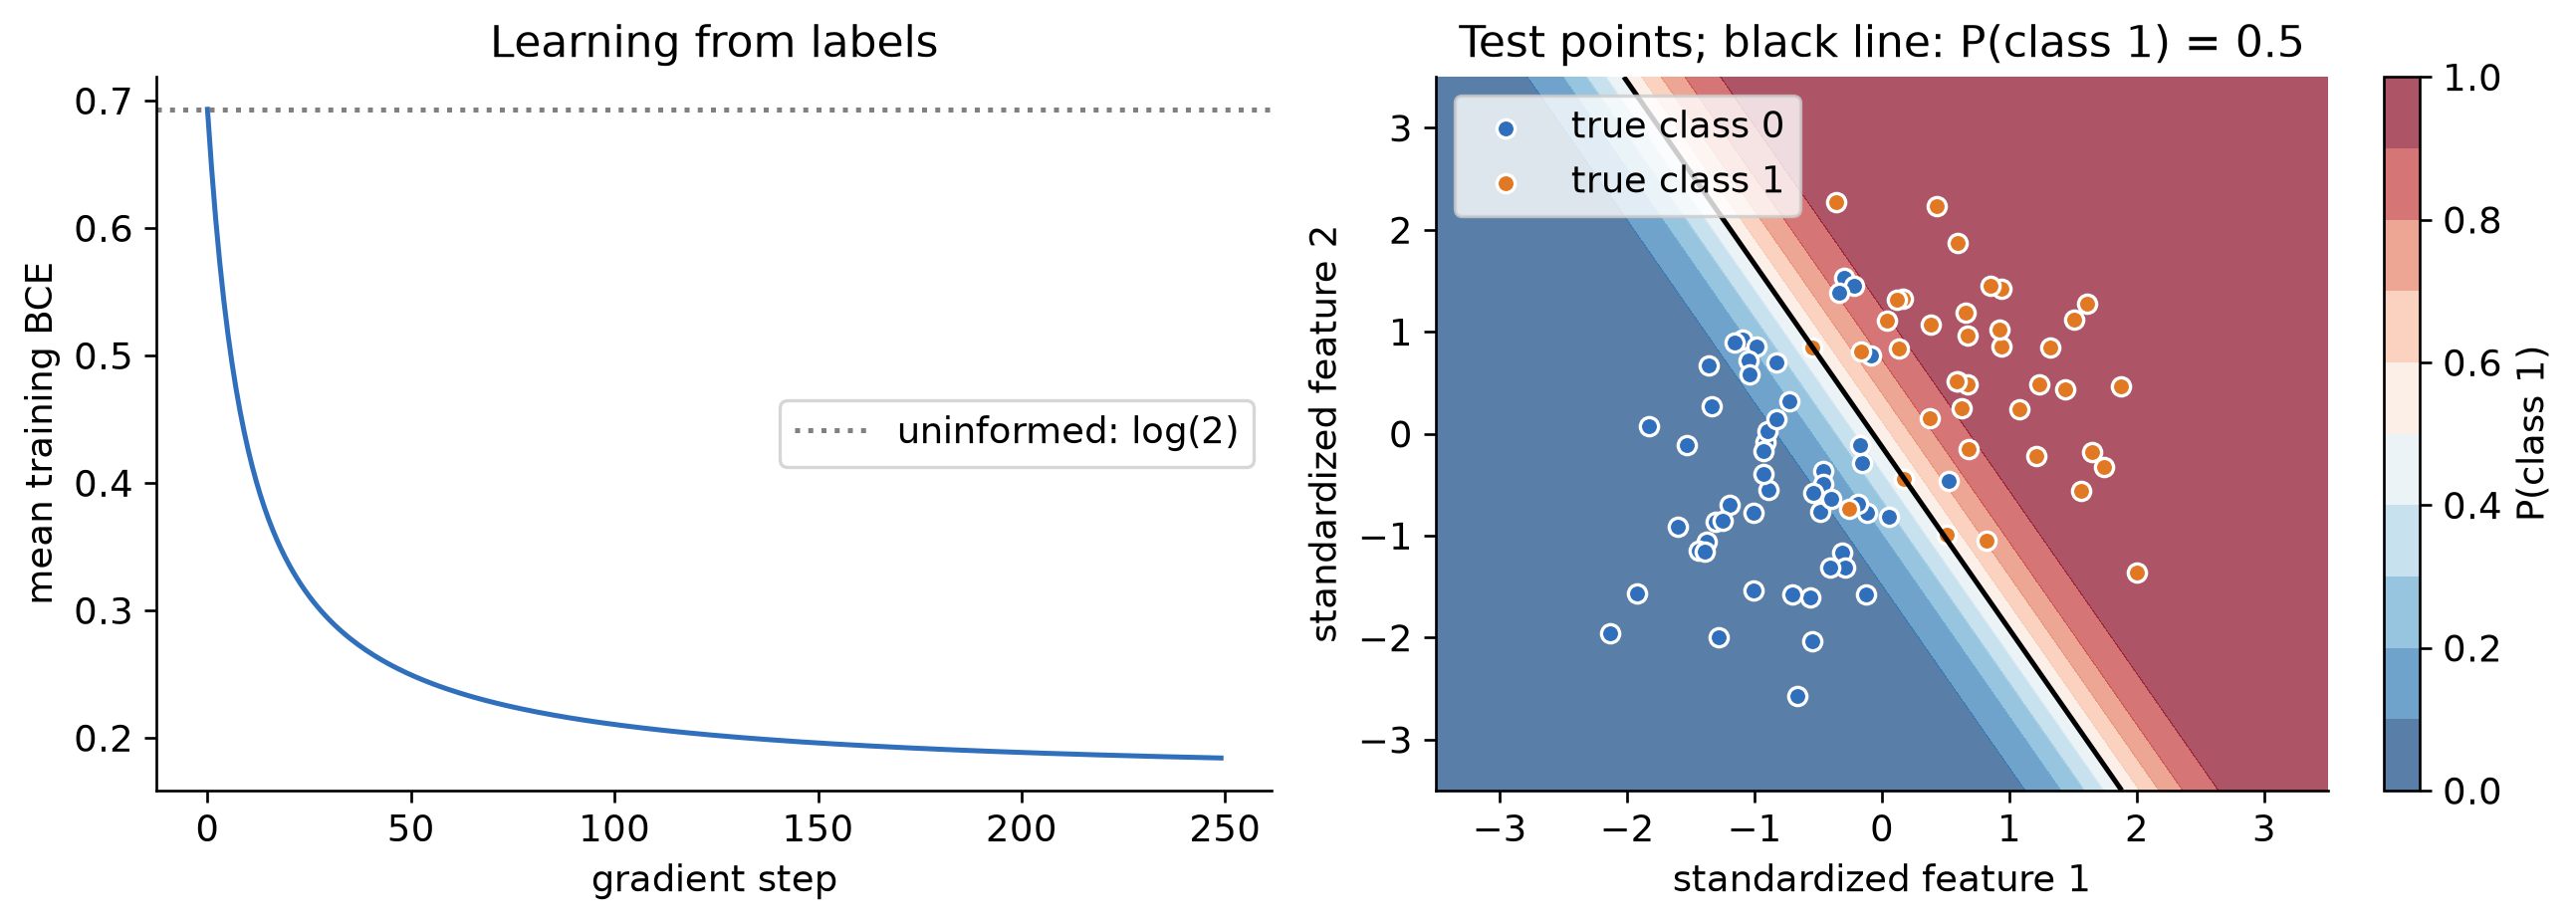

In [8]:
with torch.no_grad():
    test_logits_b = binary_model(Xb_test).squeeze(-1)
    test_probs_b = torch.sigmoid(test_logits_b)
    test_pred_b = (test_logits_b >= 0).long()
    binary_test_loss = F.binary_cross_entropy_with_logits(test_logits_b, yb_test).item()
    binary_accuracy = (test_pred_b == yb_test.long()).float().mean().item()
print(f"Test BCE: {binary_test_loss:.4f} | accuracy: {binary_accuracy:.1%}")
print("First five test examples: logit, P(class 1), prediction, truth")
for i in range(5):
    print(f"{test_logits_b[i]:7.3f}  {test_probs_b[i]:7.3f}  "
          f"{test_pred_b[i].item()}  {yb_test[i].int().item()}")

axis = torch.linspace(-3.5, 3.5, 160)
xx, yy = torch.meshgrid(axis, axis, indexing="xy")
grid = torch.stack([xx.flatten(), yy.flatten()], dim=1)
with torch.no_grad():
    grid_probs_b = torch.sigmoid(binary_model(grid).squeeze(-1)).reshape(xx.shape)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(binary_history, color=COLORS[0])
axes[0].axhline(math.log(2), color="gray", linestyle=":", label="uninformed: log(2)")
axes[0].set(xlabel="gradient step", ylabel="mean training BCE", title="Learning from labels")
axes[0].legend()
surface = axes[1].contourf(xx, yy, grid_probs_b, levels=torch.linspace(0, 1, 11),
                           cmap="RdBu_r", alpha=0.7)
axes[1].contour(xx, yy, grid_probs_b, levels=[0.5], colors="black")
for k in range(2):
    points = Xb_test[yb_test == k]
    axes[1].scatter(points[:, 0], points[:, 1], color=COLORS[k],
                    edgecolor="white", s=30, label=f"true class {k}")
axes[1].set(xlabel="standardized feature 1", ylabel="standardized feature 2",
            title="Test points; black line: P(class 1) = 0.5")
axes[1].legend(loc="upper left")
fig.colorbar(surface, ax=axes[1], label="P(class 1)")
plt.tight_layout()
plt.show()

## 4. Multiclass classification with PyTorch

Each observation now belongs to **exactly one** of three classes.
`nn.Linear(2, 3)` produces a row of three scores per example, shape `[N, 3]`.
The highest score predicts the class. `torch.softmax(z, dim=1)` converts each row into
positive probabilities that sum to 1.

For target class $y$, the categorical loss is $-\log p_y$.
`F.cross_entropy(z, y)` takes the logits directly. Targets are `[N]` **int64 class indices**,
not the floating-point binary labels we used before.

First inspect two examples without training a model. `requires_grad=True` on these scores
lets us ask how the loss would change with each score. We still use only autograd.

In [9]:
demo_logits = torch.tensor([[2., 1., 0.], [0., 1., 2.]], requires_grad=True)
demo_targets = torch.tensor([0, 1])
demo_probs = torch.softmax(demo_logits, dim=1)
demo_loss = F.cross_entropy(demo_logits, demo_targets)
demo_loss.backward()
print("probabilities:\n", demo_probs.detach())
print("row sums:", demo_probs.detach().sum(dim=1))
print("predictions:", demo_logits.argmax(dim=1))
print("mean loss:", demo_loss.item())
print("gradients from autograd:\n", demo_logits.grad)

probabilities:
 tensor([[0.66524, 0.24473, 0.09003],
        [0.09003, 0.24473, 0.66524]])
row sums: tensor([1., 1.])
predictions: tensor([0, 2])
mean loss: 0.9076058864593506
gradients from autograd:
 tensor([[-0.16738,  0.12236,  0.04502],
        [ 0.04502, -0.37764,  0.33262]])


## 5. Train a complete three-class classifier

Again generate overlapping clouds, split before scaling, and keep test examples out of training.
The structure of the training loop is unchanged. Only the output size and loss differ.

X: torch.Size([330, 2]) | y: torch.Size([330]) torch.int64


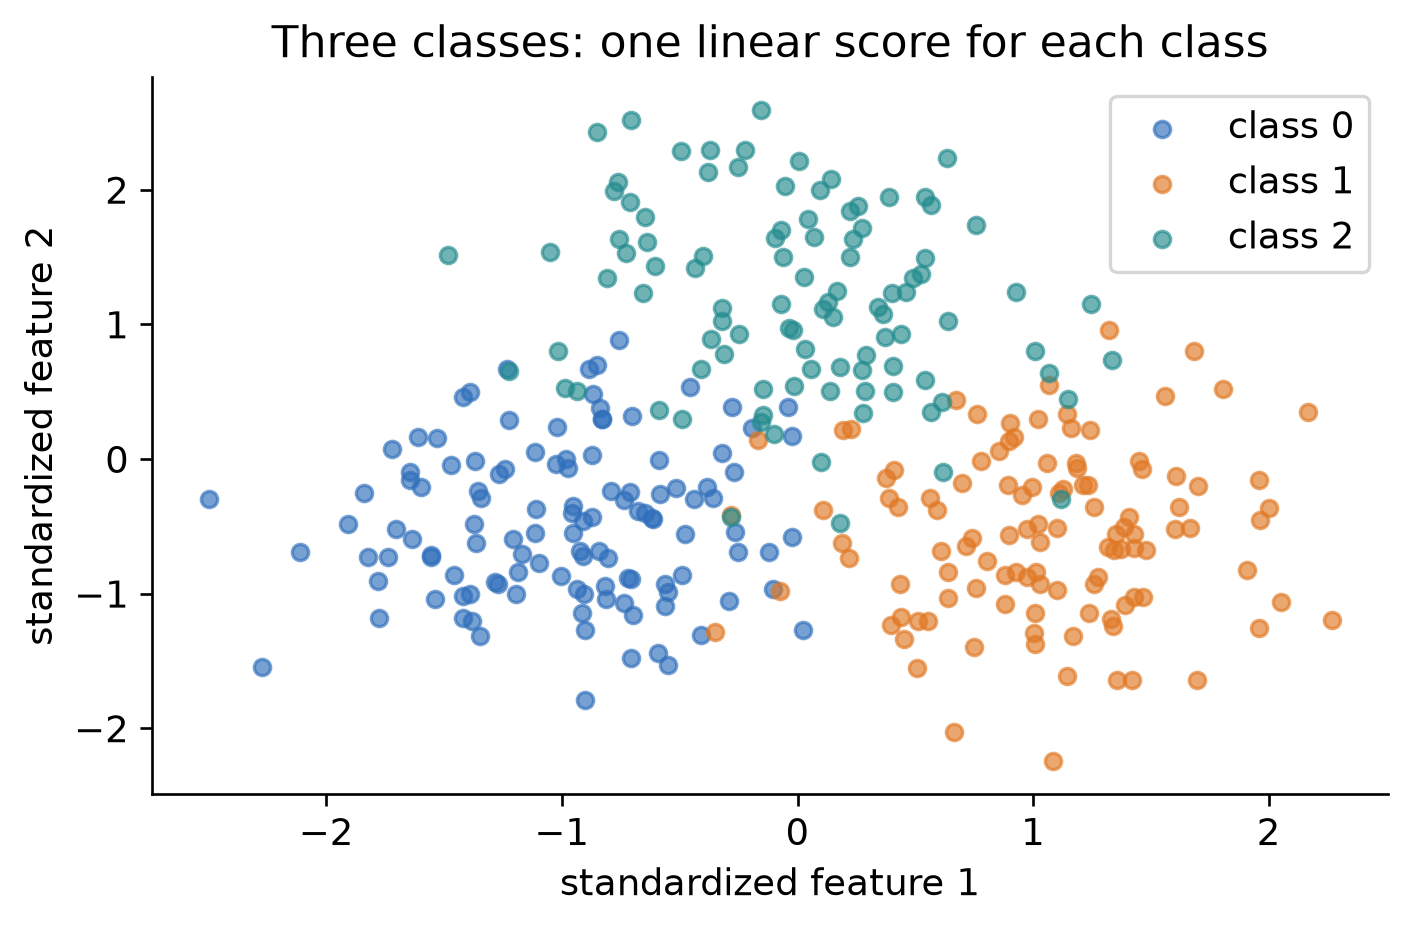

In [10]:
g_multi = torch.Generator().manual_seed(21)
centers = torch.tensor([[-1.8, -1.0], [1.8, -1.0], [0.0, 1.8]])
X_multi = torch.cat([0.95 * torch.randn(150, 2, generator=g_multi) + center
                     for center in centers])
y_multi = torch.arange(3).repeat_interleave(150)  # int64 class indices
order_m = torch.randperm(len(X_multi), generator=g_multi)
train_m, test_m = order_m[:330], order_m[330:]
mean_m = X_multi[train_m].mean(dim=0)
std_m = X_multi[train_m].std(dim=0)
Xm_train = (X_multi[train_m] - mean_m) / std_m
Xm_test = (X_multi[test_m] - mean_m) / std_m
ym_train, ym_test = y_multi[train_m], y_multi[test_m]
print("X:", Xm_train.shape, "| y:", ym_train.shape, ym_train.dtype)

fig, ax = plt.subplots(figsize=(6, 4))
for k in range(3):
    points = Xm_train[ym_train == k]
    ax.scatter(points[:, 0], points[:, 1], s=24, alpha=0.65,
               color=COLORS[k], label=f"class {k}")
ax.set(xlabel="standardized feature 1", ylabel="standardized feature 2",
       title="Three classes: one linear score for each class")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
multiclass_history = []

multiclass_model = torch.nn.Linear(2, 3)
with torch.no_grad():
    multiclass_model.weight.zero_()
    multiclass_model.bias.zero_()
multiclass_criterion = torch.nn.CrossEntropyLoss()
multiclass_optimizer = torch.optim.SGD(multiclass_model.parameters(), lr=learning_rate)

for step in range(steps):
    multiclass_optimizer.zero_grad()
    logits = multiclass_model(Xm_train)
    loss = multiclass_criterion(logits, ym_train)
    loss.backward()
    multiclass_optimizer.step()
    multiclass_history.append(loss.item())
    if step in [0, 49, 99, 249]:
        print(f"step {step:3d} | training CE {loss.item():.4f}")

step   0 | training CE 1.0986
step  49 | training CE 0.3126
step  99 | training CE 0.2533
step 249 | training CE 0.2133


The highest logit and highest softmax probability have the same class index.
Use `argmax(dim=1)` for class predictions. Use softmax only when probabilities are needed.
Each class has a linear score, so their pairwise decision boundaries are straight lines.

Test CE: 0.1810 | accuracy: 93.3%
First five probability vectors:
 tensor([[0.59586, 0.07724, 0.32690],
        [0.01926, 0.00884, 0.97189],
        [0.00321, 0.00116, 0.99563],
        [0.00259, 0.95965, 0.03776],
        [0.07060, 0.00154, 0.92786]])
predicted: tensor([0, 2, 2, 1, 2]) | true: tensor([0, 2, 2, 1, 2])
Confusion matrix: rows = true class, columns = predicted class
 tensor([[30,  2,  0],
        [ 1, 35,  2],
        [ 3,  0, 47]])


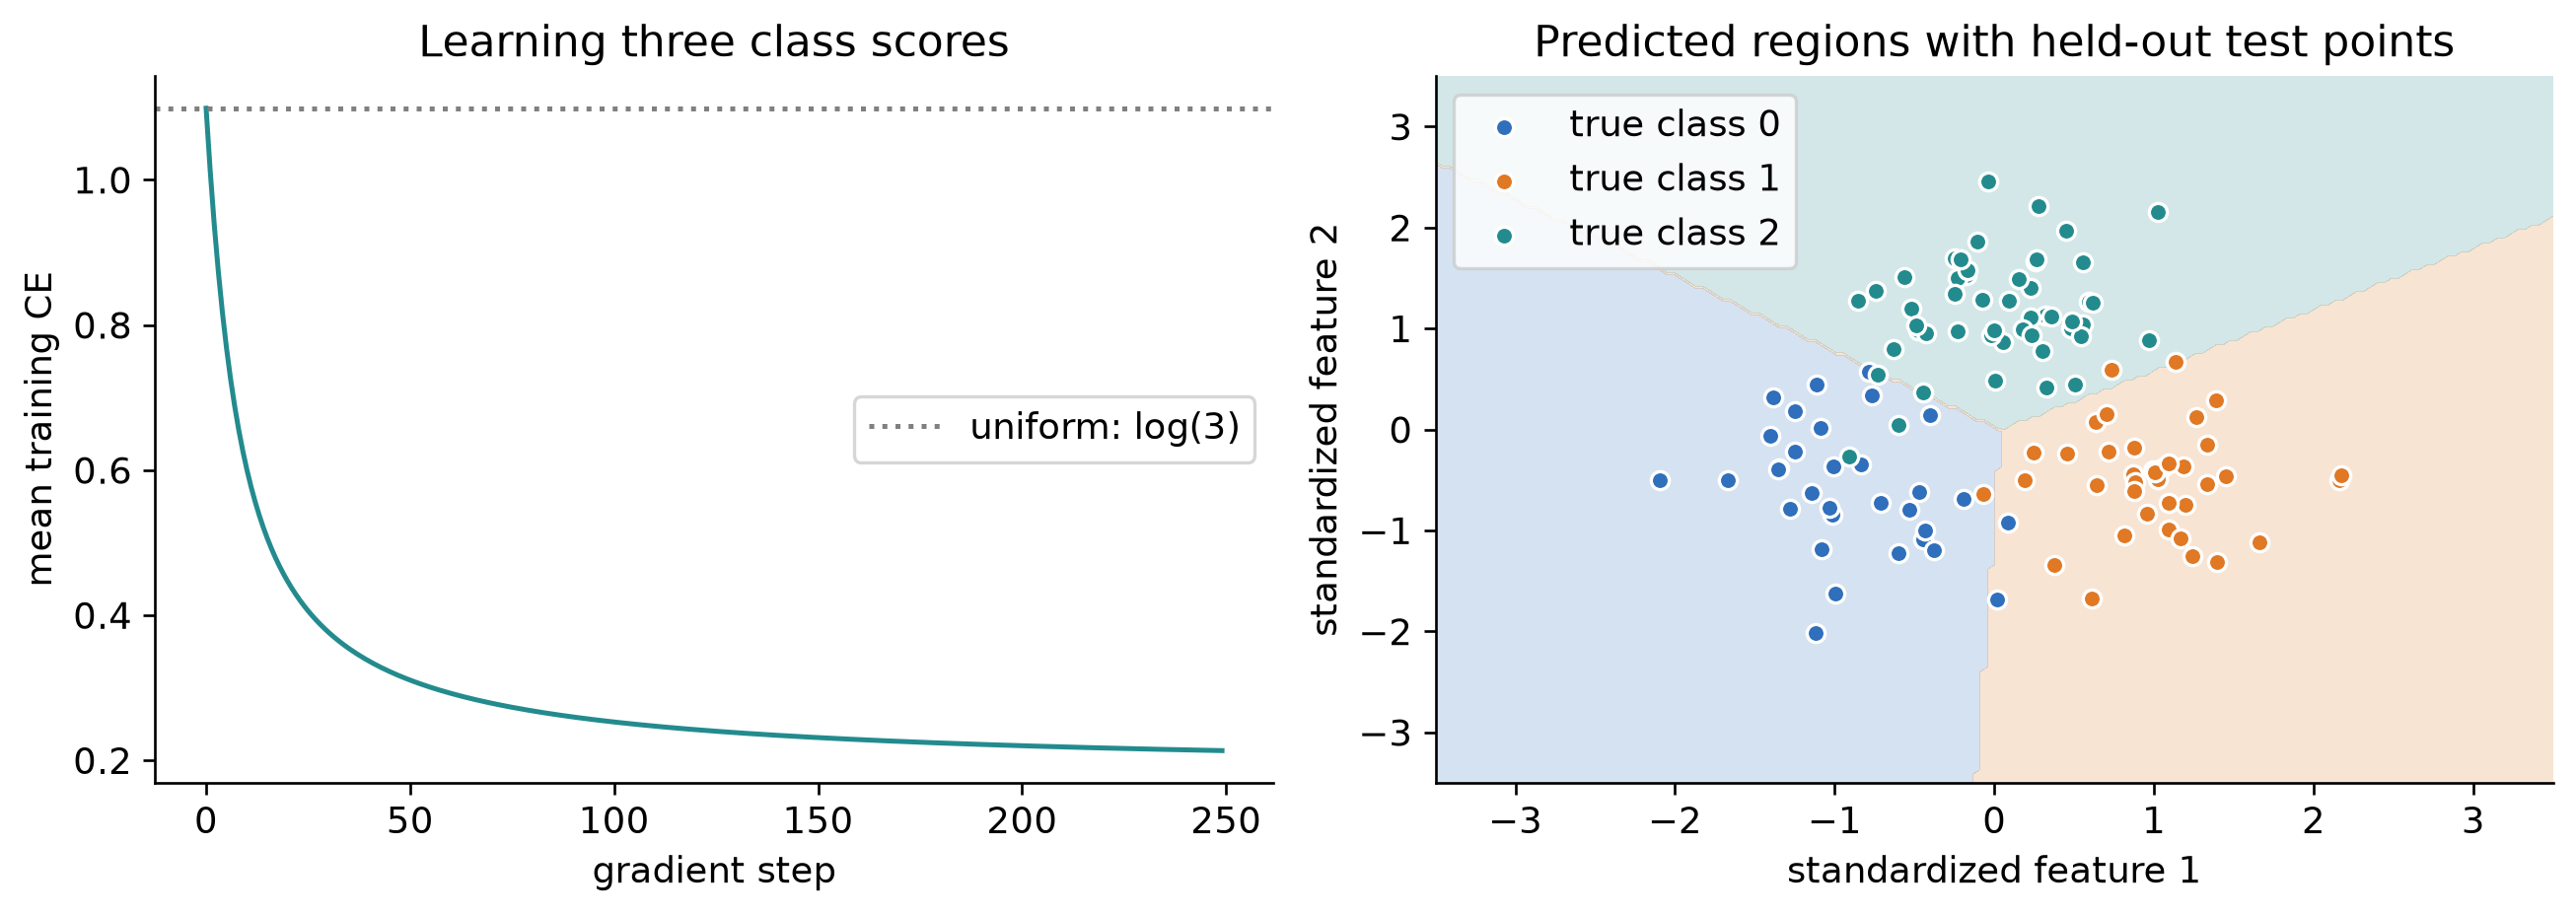

In [12]:
with torch.no_grad():
    test_logits_m = multiclass_model(Xm_test)
    test_probs_m = test_logits_m.softmax(dim=1)
    test_pred_m = test_logits_m.argmax(dim=1)
    multiclass_test_loss = F.cross_entropy(test_logits_m, ym_test).item()
    multiclass_accuracy = (test_pred_m == ym_test).float().mean().item()
    region = (multiclass_model(grid)).argmax(dim=1).reshape(xx.shape)
print(f"Test CE: {multiclass_test_loss:.4f} | accuracy: {multiclass_accuracy:.1%}")
print("First five probability vectors:\n", test_probs_m[:5])
print("predicted:", test_pred_m[:5], "| true:", ym_test[:5])
assert torch.equal(test_pred_m, test_probs_m.argmax(dim=1))

confusion = torch.bincount(3 * ym_test + test_pred_m, minlength=9).reshape(3, 3)
print("Confusion matrix: rows = true class, columns = predicted class\n", confusion)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(multiclass_history, color=COLORS[2])
axes[0].axhline(math.log(3), color="gray", linestyle=":", label="uniform: log(3)")
axes[0].set(xlabel="gradient step", ylabel="mean training CE", title="Learning three class scores")
axes[0].legend()
axes[1].contourf(xx, yy, region, levels=[-0.5, 0.5, 1.5, 2.5],
                 cmap=ListedColormap(COLORS), alpha=0.2)
for k in range(3):
    points = Xm_test[ym_test == k]
    axes[1].scatter(points[:, 0], points[:, 1], color=COLORS[k],
                    edgecolor="white", s=30, label=f"true class {k}")
axes[1].set(xlabel="standardized feature 1", ylabel="standardized feature 2",
            title="Predicted regions with held-out test points")
axes[1].legend(loc="upper left")
plt.tight_layout()
plt.show()

## 6. Now implement the forward functions ourselves

We have working classifiers. What are sigmoid, softmax, and their losses doing inside?
For ordinary inputs, translate their mathematical definitions directly into tensor operations.

**We keep PyTorch tensors and autograd.** We replace forward functions, not `.backward()`.
Every `exp`, `log`, multiplication, and division is tracked by PyTorch.

In [13]:
def sigmoid_naive(z):
    return 1 / (1 + torch.exp(-z))

def bce_from_probs_naive(p, y):
    return -(y * torch.log(p) + (1 - y) * torch.log(1 - p))

scratch_z = torch.tensor([-2., 0., 2.], requires_grad=True)
scratch_y = torch.tensor([0., 1., 1.])
scratch_p = sigmoid_naive(scratch_z)
scratch_loss = bce_from_probs_naive(scratch_p, scratch_y).mean()
scratch_loss.backward()  # still PyTorch's autograd!

reference_z = scratch_z.detach().clone().requires_grad_()
reference_loss = F.binary_cross_entropy_with_logits(reference_z, scratch_y)
reference_loss.backward()
print("scratch probabilities:", scratch_p.detach())
print("loss:", scratch_loss.item(), "| autograd gradients:", scratch_z.grad)
torch.testing.assert_close(scratch_loss, reference_loss)
torch.testing.assert_close(scratch_z.grad, reference_z.grad)
print("The direct formula agrees with PyTorch on these ordinary inputs.")

scratch probabilities: tensor([0.11920, 0.50000, 0.88080])
loss: 0.3156677484512329 | autograd gradients: tensor([ 0.03973, -0.16667, -0.03973])
The direct formula agrees with PyTorch on these ordinary inputs.


### Do the same for softmax and categorical cross-entropy

$$p_k=\frac{e^{z_k}}{\sum_j e^{z_j}},\qquad \ell=-\log p_y.$$

`dim=1` sums over classes in each row. `keepdim=True` leaves a `[N, 1]` denominator
that broadcasts across columns. `p[rows, y]` selects each row's observed class probability.

In [14]:
def softmax_naive(z):
    e = torch.exp(z)
    return e / e.sum(dim=1, keepdim=True)

def ce_from_probs_naive(p, y):
    rows = torch.arange(len(y), device=y.device)
    return -torch.log(p[rows, y])

scratch_scores = torch.tensor([[2., 1., 0.], [0., 1., 2.]], requires_grad=True)
scratch_targets = torch.tensor([0, 1])
scratch_probabilities = softmax_naive(scratch_scores)
scratch_ce = ce_from_probs_naive(scratch_probabilities, scratch_targets).mean()
scratch_ce.backward()  # no hand-written gradient calculation

reference_scores = scratch_scores.detach().clone().requires_grad_()
reference_ce = F.cross_entropy(reference_scores, scratch_targets)
reference_ce.backward()
print("scratch probabilities:\n", scratch_probabilities.detach())
print("loss:", scratch_ce.item(), "| autograd gradients:\n", scratch_scores.grad)
torch.testing.assert_close(scratch_ce, reference_ce)
torch.testing.assert_close(scratch_scores.grad, reference_scores.grad)
print("The direct multiclass formula also agrees on ordinary inputs.")

scratch probabilities:
 tensor([[0.66524, 0.24473, 0.09003],
        [0.09003, 0.24473, 0.66524]])
loss: 0.9076060056686401 | autograd gradients:
 tensor([[-0.16738,  0.12236,  0.04502],
        [ 0.04502, -0.37764,  0.33262]])
The direct multiclass formula also agrees on ordinary inputs.


Those implementations appear to work. Can we safely replace the built-in functions with them?
**Next checkpoint:** try scores with magnitude 100 or 1000, and inspect both outputs and gradients.
The distinction is numerical evaluation, not a change to the statistical model.

## 7. Where the direct sigmoid and binary loss fail

### Implement sigmoid without overflowing its exponential

In float32, $e^{1000}$ cannot be represented. The naive sigmoid at $z=-1000$
computes $1/(1+\infty)=0$: a plausible forward value can hide a broken computation graph.
Check the gradient too.

We can use the same function in two algebraically equivalent forms:

$$\sigma(z)=\begin{cases}
1/(1+e^{-z}) & z\geq0,\\
e^z/(1+e^z) & z<0.
\end{cases}$$

Every exponential now has a nonpositive input. Boolean indexing evaluates each branch
**only where it is safe**. `torch.where(mask, expression_a, expression_b)` evaluates
both expressions first, so it cannot by itself protect an overflowing exponential.

In [15]:
def sigmoid_scratch(z):
    result = torch.empty_like(z)
    positive = z >= 0
    result[positive] = 1 / (1 + torch.exp(-z[positive]))
    ez = torch.exp(z[~positive])
    result[~positive] = ez / (1 + ez)
    return result

for name, fn in [("naive", sigmoid_naive), ("sign-aware", sigmoid_scratch),
                 ("torch.sigmoid", torch.sigmoid)]:
    probe = torch.tensor([-1000.0, 0.0, 1000.0], requires_grad=True)
    result = fn(probe)
    result.sum().backward()
    print(name, "\n  p =", result.detach(), "\n  dp/dz =", probe.grad)

probe = torch.tensor([-10., -1., 0., 1., 10.], requires_grad=True)
torch.testing.assert_close(sigmoid_scratch(probe), probe.sigmoid())
grad_scratch = torch.autograd.grad(sigmoid_scratch(probe).sum(), probe)[0]
torch.testing.assert_close(grad_scratch, probe.sigmoid() * (1 - probe.sigmoid()))

naive 
  p = tensor([0.00000, 0.50000, 1.00000]) 
  dp/dz = tensor([    nan, 0.25000, 0.00000])
sign-aware 
  p = tensor([0.00000, 0.50000, 1.00000]) 
  dp/dz = tensor([0.00000, 0.25000, 0.00000])
torch.sigmoid 
  p = tensor([0.00000, 0.50000, 1.00000]) 
  dp/dz = tensor([0.00000, 0.25000, 0.00000])


### A stable sigmoid is still not a stable binary loss

**Predict:** use PyTorch's sigmoid at $z=100$, with true label $y=0$.
Will calculating $-\log(1-p)$ afterward give a finite result?

The probability rounds to exactly 1. Its missing tail cannot be recovered by a later log.
A confidently **wrong** prediction should have a large finite loss and a strong corrective gradient.
`inf` below means infinity; `nan` means an undefined numerical result.
These failures are deliberate demonstrations, not exceptions to ignore during real training.

In [16]:
z_bad = torch.tensor([-100.0, 100.0], requires_grad=True)
y_bad = torch.tensor([1.0, 0.0])  # both predictions are confidently wrong
p_bad = torch.sigmoid(z_bad)
bad_losses = bce_from_probs_naive(p_bad, y_bad)
bad_grad = torch.autograd.grad(bad_losses.sum(), z_bad)[0]
good_losses = F.binary_cross_entropy_with_logits(z_bad, y_bad, reduction="none")
good_grad = torch.autograd.grad(good_losses.sum(), z_bad)[0]
print("rounded probabilities:", p_bad.detach())
print("direct BCE:", bad_losses.detach(), "| gradient:", bad_grad)
print("BCE with logits:", good_losses.detach(), "| gradient:", good_grad)
assert torch.isfinite(good_losses).all() and torch.isfinite(good_grad).all()
torch.testing.assert_close(good_grad, torch.tensor([-1.0, 1.0]))

rounded probabilities: tensor([0., 1.])
direct BCE: tensor([inf, inf]) | gradient: tensor([nan, nan])
BCE with logits: tensor([100., 100.]) | gradient: tensor([-1.,  1.])


### Why adding epsilon or clipping is not the same repair

Clipping makes the printed loss finite, but changes the objective and can set its gradient
to zero outside the clipping interval. Adding epsilon inside the log also changes the
objective and cannot restore information already lost in a rounded probability.

In [17]:
z_clip = torch.tensor([100.0], requires_grad=True)
p_clip = torch.sigmoid(z_clip).clamp(1e-7, 1 - 1e-7)
clipped_loss = bce_from_probs_naive(p_clip, torch.tensor([0.0])).sum()
clipped_grad = torch.autograd.grad(clipped_loss, z_clip)[0]
print("clipped loss:", clipped_loss.item(), "| gradient:", clipped_grad)
print("correct logits loss is about 100; its gradient is about +1")
assert clipped_grad.item() == 0

clipped loss: 15.942384719848633 | gradient: tensor([0.])
correct logits loss is about 100; its gradient is about +1


## 8. Better binary routines: softplus and loss from logits

From $\log p=z-\log(1+e^z)$ and $\log(1-p)=-\log(1+e^z)$:

$$\ell(z,y)=\log(1+e^z)-yz=\operatorname{softplus}(z)-yz.$$

This removes explicit probabilities, but `log(1 + exp(z))` can still overflow!
L5B's rearrangement is

$$\operatorname{softplus}(z)=\max(z,0)+\log(1+e^{-|z|}).$$

**Two distinct improvements:** avoid a huge exponential; use `log1p(t)` to compute
$\log(1+t)$ accurately when $t$ is tiny. `log1p(exp(z))` alone cannot fix overflow.

In [18]:
small = torch.tensor(1e-8)
print("log(1 + 1e-8):", torch.log(1 + small).item())
print("log1p(1e-8):  ", torch.log1p(small).item())

# Branches also give the correct autograd derivative at z=0.
# Blindly composing max/abs at their kinks needs a separate gradient check.
def softplus_scratch(z):
    result = torch.empty_like(z)
    positive = z >= 0
    result[positive] = z[positive] + torch.log1p(torch.exp(-z[positive]))
    result[~positive] = torch.log1p(torch.exp(z[~positive]))
    return result

z_sp = torch.tensor([-1000.0, 2.0, 1000.0])
print("log1p(exp(z)):", torch.log1p(torch.exp(z_sp)))
print("scratch:      ", softplus_scratch(z_sp))
print("F.softplus:   ", F.softplus(z_sp))

log(1 + 1e-8): 0.0
log1p(1e-8):   9.99999993922529e-09
log1p(exp(z)): tensor([0.00000, 2.12693,     inf])
scratch:       tensor([   0.00000,    2.12693, 1000.00000])
F.softplus:    tensor([   0.00000,    2.12693, 1000.00000])


For implementation, we can also write the same BCE as

$$\ell(z,y)=(1-y)\operatorname{softplus}(z)+y\operatorname{softplus}(-z).$$

At $y=0$ this selects softplus$(z)$; at $y=1$ it selects softplus$(-z)$.
This avoids subtracting two large, nearly equal terms for a confident correct prediction.
It also works for soft binary targets in $[0,1]$, although our dataset uses only 0 and 1.

We test **values and gradients**, including the branch point $z=0$.
In ordinary code use PyTorch's fused operation
[`F.binary_cross_entropy_with_logits`](https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html).

In [19]:
def bce_logits_scratch(z, y):
    return (1 - y) * softplus_scratch(z) + y * softplus_scratch(-z)

for label in [0.0, 0.3, 1.0]:
    z_check = torch.tensor([-1000., -10., -1., 0., 1., 10., 1000.],
                           dtype=torch.float64, requires_grad=True)
    y_check = torch.full_like(z_check, label)
    ours = bce_logits_scratch(z_check, y_check)
    reference = F.binary_cross_entropy_with_logits(z_check, y_check, reduction="none")
    ours_grad = torch.autograd.grad(ours.sum(), z_check)[0]
    reference_grad = torch.autograd.grad(reference.sum(), z_check)[0]
    torch.testing.assert_close(ours, reference)
    torch.testing.assert_close(ours_grad, reference_grad)
print("Scratch BCE matches PyTorch: values and gradients, including zero and extremes.")

Scratch BCE matches PyTorch: values and gradients, including zero and extremes.


### Train our binary forward implementation; autograd still does backward

For a batch, $X$ has shape `[N, 2]`, $w$ has shape `[2]`, and $b$ is a scalar.
`X @ w + b` produces **one logit per row**, shape `[N]`.
Targets must have the **same shape** and a floating-point dtype.

The loop has five jobs: compute logits, compute mean loss, differentiate,
update parameters, clear gradients. PyTorch **adds** gradients into `.grad`,
so clearing them matters. `.item()` stores a plain number for plotting.
This is full-batch gradient descent; there is no hidden training framework.

In [20]:
w_b = torch.zeros(2, requires_grad=True)
b_b = torch.zeros((), requires_grad=True)
scratch_binary_history = []
learning_rate = 0.2
steps = 250

for step in range(steps):
    logits = Xb_train @ w_b + b_b
    loss = bce_logits_scratch(logits, yb_train).mean()
    loss.backward()
    with torch.no_grad():
        w_b -= learning_rate * w_b.grad
        b_b -= learning_rate * b_b.grad
    w_b.grad = None
    b_b.grad = None
    scratch_binary_history.append(loss.item())
    if step in [0, 49, 99, 249]:
        print(f"step {step:3d} | training BCE {loss.item():.4f}")

print("learned w =", w_b.detach(), "| b =", b_b.item())
assert scratch_binary_history[-1] < scratch_binary_history[0]

step   0 | training BCE 0.6931


step  49 | training BCE 0.2507
step  99 | training BCE 0.2108
step 249 | training BCE 0.1841
learned w = tensor([2.89757, 1.61743]) | b = 0.20987576246261597


In [21]:
torch.testing.assert_close(binary_model.weight[0], w_b, atol=2e-5, rtol=2e-5)
torch.testing.assert_close(binary_model.bias[0], b_b, atol=2e-5, rtol=2e-5)
print("Our stable binary forward implementation learns the same parameters as the first PyTorch model.")

Our stable binary forward implementation learns the same parameters as the first PyTorch model.


## 9. Where direct softmax and cross-entropy fail

**Predict:** should $(2,1,0)$, $(1000,999,998)$, and $(-1000,-1001,-1002)$
give different probabilities? Their pairwise differences are identical.
`dim=1` means normalize over the classes in each row; `keepdim=True` keeps the
denominator shape `[N, 1]`, so division broadcasts over columns.

In [22]:
z_rows = torch.tensor([[2., 1., 0.], [1000., 999., 998.],
                       [-1000., -1001., -1002.]])
print("exponentials:\n", torch.exp(z_rows))
print("naive probabilities:\n", softmax_naive(z_rows))

exponentials:
 tensor([[7.38906, 2.71828, 1.00000],
        [    inf,     inf,     inf],
        [0.00000, 0.00000, 0.00000]])
naive probabilities:
 tensor([[0.66524, 0.24473, 0.09003],
        [    nan,     nan,     nan],
        [    nan,     nan,     nan]])


### Subtract each row's maximum before exponentiating

Multiplying all numerator and denominator terms by $e^{-m}$ preserves the ratios:

$$p_k=\frac{e^{z_k-m}}{\sum_j e^{z_j-m}},\qquad m=\max_j z_j.$$

All exponentials are at most 1, and at least one is 1, so the denominator cannot be zero
for these finite input logits. Compute the maximum **per example**, not across the whole batch.

In [23]:
def softmax_scratch(z):
    shifted = z - z.max(dim=1, keepdim=True).values
    e = torch.exp(shifted)
    return e / e.sum(dim=1, keepdim=True)

stable_probs = softmax_scratch(z_rows)
print("shifted logits:\n", z_rows - z_rows.max(dim=1, keepdim=True).values)
print("stable probabilities:\n", stable_probs)
print("row sums:", stable_probs.sum(dim=1))
torch.testing.assert_close(stable_probs, torch.softmax(z_rows, dim=1))
torch.testing.assert_close(stable_probs, stable_probs[0].expand_as(stable_probs))

shifted logits:
 tensor([[ 0., -1., -2.],
        [ 0., -1., -2.],
        [ 0., -1., -2.]])
stable probabilities:
 tensor([[0.66524, 0.24473, 0.09003],
        [0.66524, 0.24473, 0.09003],
        [0.66524, 0.24473, 0.09003]])
row sums: tensor([1., 1., 1.])


### A stable softmax is still not a stable log-probability

If the observed class index is $y$, its probability is $p_y$ and its loss is $-\log p_y$.
We select the correct column of each row using `p[rows, y]`.
A one-hot vector is useful on paper, but PyTorch accepts class indices directly.

**Predict:** for logits $(2,1,0)$ and target class **0**, the loss is about 0.408.
What happens for logits $(0,1000)$ and target class **0**?

In [24]:
ordinary_logits = torch.tensor([[2., 1., 0.]])
ordinary_target = torch.tensor([0])
ordinary_probs = softmax_scratch(ordinary_logits)
print("ordinary loss:", -ordinary_probs[0, ordinary_target[0]].log().item())

extreme_logits = torch.tensor([[0., 1000.]], requires_grad=True)
extreme_target = torch.tensor([0])
extreme_probs = softmax_scratch(extreme_logits)
probability_loss = -extreme_probs[0, 0].log()
probability_grad = torch.autograd.grad(probability_loss, extreme_logits)[0]
print("stable softmax probabilities:", extreme_probs.detach())
print("log AFTER softmax: loss =", probability_loss.item(), "| gradient =", probability_grad)

ordinary loss: 0.40760597586631775
stable softmax probabilities: tensor([[0., 1.]])
log AFTER softmax: loss = inf | gradient = tensor([[nan, nan]])


## 10. Better multiclass routines: log-sum-exp and log-softmax

Subtract-max makes softmax safer, but the tiny target probability can still underflow to zero.
We can calculate its log without ever storing that tiny probability:

$$\operatorname{LSE}(z)=m+\log\sum_j e^{z_j-m},$$
$$\log p_k=(z_k-m)-\log\sum_j e^{z_j-m},$$
$$\ell(z,y)=-(z_y-m)+\log\sum_j e^{z_j-m}.$$

The shifted form also avoids adding $m$ only to subtract it again. For $(0,1000)$,
the true class log-probability remains approximately $-1000$, so the loss is approximately 1000.

In [25]:
def log_softmax_scratch(z):
    shifted = z - z.max(dim=1, keepdim=True).values
    log_denominator = torch.log(torch.exp(shifted).sum(dim=1, keepdim=True))
    return shifted - log_denominator

def cross_entropy_scratch(z, y):
    log_probs = log_softmax_scratch(z)
    rows = torch.arange(z.shape[0], device=z.device)
    return -log_probs[rows, y]  # one loss per observation

print("scratch log probabilities:", log_softmax_scratch(extreme_logits).detach())
print("PyTorch log probabilities:", F.log_softmax(extreme_logits, dim=1).detach())
print("PyTorch log-sum-exp:", torch.logsumexp(extreme_logits, dim=1).detach())
stable_loss_m = cross_entropy_scratch(extreme_logits, extreme_target).mean()
stable_grad_m = torch.autograd.grad(stable_loss_m, extreme_logits)[0]
print("loss:", stable_loss_m.item(), "| gradient:", stable_grad_m)
torch.testing.assert_close(stable_loss_m, torch.tensor(1000.0))
torch.testing.assert_close(stable_grad_m, torch.tensor([[-1.0, 1.0]]))

scratch log probabilities: tensor([[-1000.,     0.]])
PyTorch log probabilities: tensor([[-1000.,     0.]])
PyTorch log-sum-exp: tensor([1000.])
loss: 1000.0 | gradient: tensor([[-1.,  1.]])


### Check values and gradients using PyTorch as the reference

Both paths below use autograd: one differentiates our tensor operations; the other differentiates
PyTorch's built-in loss. `torch.autograd.grad` returns the gradients directly, so we can compare them.
It is another interface to PyTorch's differentiation engine, not our own gradient implementation.

Test ordinary scores, tied scores, and confidently wrong extreme scores. The confidently wrong
example should still receive gradients that increase the correct class score and decrease the wrong one.
[`CrossEntropyLoss`](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)
takes logits and is equivalent here to log-softmax followed by negative log-likelihood.

In [26]:
z_verify = torch.tensor([[2., 1., 0.], [0., 0., 0.], [0., 1000., -1000.]],
                        dtype=torch.float64, requires_grad=True)
y_verify = torch.tensor([0, 2, 0])
our_ce = cross_entropy_scratch(z_verify, y_verify)
reference_ce = F.cross_entropy(z_verify, y_verify, reduction="none")
torch.testing.assert_close(our_ce, reference_ce)
our_ce_grad = torch.autograd.grad(our_ce.mean(), z_verify)[0]
reference_ce_grad = torch.autograd.grad(reference_ce.mean(), z_verify)[0]
torch.testing.assert_close(our_ce_grad, reference_ce_grad)
torch.testing.assert_close(F.nll_loss(F.log_softmax(z_verify, dim=1), y_verify),
                           reference_ce.mean())
print("CE values and mean-loss gradients match, including tied and extreme logits.")
print("gradient:\n", our_ce_grad)

CE values and mean-loss gradients match, including tied and extreme logits.
gradient:
 tensor([[-0.11159,  0.08158,  0.03001],
        [ 0.11111,  0.11111, -0.22222],
        [-0.33333,  0.33333,  0.00000]], dtype=torch.float64)


### Train the multiclass forward implementation; keep autograd

Write the linear layer as $Z=XW+b$. Here $X$ is `[N, 2]`, $W$ is `[2, 3]`,
and $b$ is `[3]`. The result is `[N, 3]` logits. Use our stable cross-entropy and
let `.backward()` compute all parameter derivatives, exactly as before.

Zero initialization is fine for this linear model: different class labels generate different
updates. It is not a suitable general initialization rule for hidden layers.

In [27]:
W_m = torch.zeros(2, 3, requires_grad=True)
b_m = torch.zeros(3, requires_grad=True)
scratch_multiclass_history = []

for step in range(steps):
    logits = Xm_train @ W_m + b_m
    loss = cross_entropy_scratch(logits, ym_train).mean()
    loss.backward()
    with torch.no_grad():
        W_m -= learning_rate * W_m.grad
        b_m -= learning_rate * b_m.grad
    W_m.grad = None
    b_m.grad = None
    scratch_multiclass_history.append(loss.item())
    if step in [0, 49, 99, 249]:
        print(f"step {step:3d} | training CE {loss.item():.4f}")
assert scratch_multiclass_history[-1] < scratch_multiclass_history[0]

step   0 | training CE 1.0986
step  49 | training CE 0.3126
step  99 | training CE 0.2533
step 249 | training CE 0.2133


In [28]:
# nn.Linear stores weights as [out_features, in_features], hence the transpose.
torch.testing.assert_close(multiclass_model.weight.T, W_m, atol=2e-5, rtol=2e-5)
torch.testing.assert_close(multiclass_model.bias, b_m, atol=2e-5, rtol=2e-5)
print("Our stable multiclass forward implementation matches the first PyTorch model.")

Our stable multiclass forward implementation matches the first PyTorch model.


## 11. Connect the binary and multiclass cases

A two-class softmax with scores $(a,b)$ gives

$$P(y=1)=\frac{e^b}{e^a+e^b}=\sigma(b-a).$$

Fix class 0's score to 0 and let class 1's score be $z$. Then two-class cross-entropy
is exactly binary cross-entropy with logit $z$.
Binary logistic regression needs only the **difference** of two class scores.
Adding the same score to both classes changes neither probability.
The loss equivalence does not imply identical parameter updates if both class scores
are independently parameterized and trained with the same learning rate.

In [29]:
z_bridge = torch.tensor([-100., -2., 0., 2., 100.])
y_bridge = torch.tensor([1, 0, 1, 1, 0])
two_logits = torch.stack([torch.zeros_like(z_bridge), z_bridge], dim=1)
torch.testing.assert_close(two_logits.softmax(dim=1)[:, 1], z_bridge.sigmoid())
torch.testing.assert_close(
    F.cross_entropy(two_logits, y_bridge, reduction="none"),
    F.binary_cross_entropy_with_logits(z_bridge, y_bridge.float(), reduction="none"),
)
print("[0, z] with two-class CE equals z with binary BCE.")

[0, z] with two-class CE equals z with binary BCE.


### A common bug: passing probabilities to a loss that expects logits

`cross_entropy(softmax(z), y)` interprets the probabilities as a **new set of scores**.
It computes a different objective and different gradients. Similarly,
`binary_cross_entropy_with_logits(sigmoid(z), y)` is not the intended binary loss.

In [30]:
z_bug = torch.tensor([[2., 1., 0.]], requires_grad=True)
y_bug = torch.tensor([0])
correct = F.cross_entropy(z_bug, y_bug)
wrong = F.cross_entropy(z_bug.softmax(dim=1), y_bug)
print("CE(logits):", correct.item(), "| CE(probabilities):", wrong.item())
print("correct gradient:", torch.autograd.grad(correct, z_bug)[0])
print("wrong gradient:  ", torch.autograd.grad(wrong, z_bug)[0])

CE(logits): 0.40760594606399536 | CE(probabilities): 0.7971903681755066
correct gradient: tensor([[-0.33476,  0.24473,  0.09003]])
wrong gradient:   tensor([[-0.18571,  0.13855,  0.04715]])


## 12. Keep this API table beside your training loop

| Task | Model output | Targets in this notebook | Training loss | Inference |
|---|---|---|---|---|
| Binary | `[N]` logits | `[N]` float, 0 or 1 | `F.binary_cross_entropy_with_logits(z, y)` | `z >= 0`; sigmoid for probabilities |
| Multiclass, one class per example | `[N, K]` logits | `[N]` long, indices 0…K−1 | `F.cross_entropy(z, y)` | `z.argmax(dim=1)`; softmax for probabilities |
| Multilabel, several labels may apply | `[N, K]` independent logits | `[N, K]` float, each entry 0 or 1 | `F.binary_cross_entropy_with_logits(z, y)` | threshold each logit; independent sigmoids |

Multilabel is a different task: an image may contain both a cat and a dog. Those label
probabilities need not sum to 1. Our three-class experiment instead has exactly one label per row.

**Which routine when?**

- Need binary probabilities: `torch.sigmoid(z)`.
- Need class probabilities: `torch.softmax(z, dim=1)`.
- Need class log-probabilities: `F.log_softmax(z, dim=1)`, rather than `softmax(z).log()`.
- Need binary log-probabilities: `F.logsigmoid(z)` for class 1; `F.logsigmoid(-z)` for class 0.
- Need a log of a sum of exponentials: `torch.logsumexp(z, dim=1)`.
- Need a training loss: pass logits to the appropriate fused loss.

Numerical stability preserves useful values and gradients for these large **finite** logits.
It does not repair NaN inputs, an overflowing matrix multiplication, or a model class that cannot
express the boundary. Finite precision still drops sufficiently tiny corrections.

## 13. Optional predict → change → explain exercises

1. **Gradient direction:** at $z=-3,y=1$, should gradient descent raise or lower $z$?
   Use a scalar tensor, `binary_cross_entropy_with_logits`, and `.backward()` to check.
2. **Precision:** change the sigmoid/BCE probes to float64. Does $z=1000$ become safe for the
   naive exponential? Does a wider dtype eliminate every rounding problem?
3. **Wrong dimension:** replace `dim=1` by `dim=0` in softmax for a two-row batch. Which sums
   become 1? Why would one student's prediction now depend on another student's input?
4. **Threshold:** suppose class 1 requires probability at least 0.8. Derive the equivalent
   logit threshold and verify that both rules agree. This changes predictions, not training.
5. **Model limitation:** can a linear logistic classifier perfectly fit XOR: $(0,0)\to0$,
   $(0,1)\to1$, $(1,0)\to1$, $(1,1)\to0$? Would a stable loss fix that?

Try these before reading the answers below. The next cell checks exercises 3 and 4.

In [31]:
batch = torch.tensor([[2., 1., 0.], [-1., 0., 3.]])
print("dim=1, row sums:", batch.softmax(dim=1).sum(dim=1))
print("dim=0, row sums:", batch.softmax(dim=0).sum(dim=1))
print("dim=0, column sums:", batch.softmax(dim=0).sum(dim=0))

probability_threshold = 0.8
logit_threshold = math.log(probability_threshold / (1 - probability_threshold))
print("0.8 probability corresponds to logit", logit_threshold)
assert torch.equal(test_probs_b >= probability_threshold,
                   test_logits_b >= logit_threshold)

dim=1, row sums: tensor([1., 1.])
dim=0, row sums: tensor([1.73106, 1.26894])
dim=0, column sums: tensor([1., 1., 1.])
0.8 probability corresponds to logit 1.3862943611198908


### Exercise answers

1. Autograd returns a derivative of approximately $-0.953$. Subtracting it raises the logit.
2. Float64 postpones some failures, but $e^{1000}$ overflows there too. A sigmoid can still
   round to 1 well before its internal exponential overflows. Use stable algebra, not just a wider dtype.
3. `dim=0` normalizes each class across examples. Columns sum to 1; rows generally do not.
4. $\log(0.8/0.2)=\log4\approx1.3863$. Use `z >= logit_threshold`.
5. XOR is not linearly separable in its original features. Add nonlinear features or a hidden
   layer; changing the numerical evaluation of the same linear model does not add expressive power.

### Final classroom checkpoint

Explain aloud: **What is learned? Where do probabilities enter the mathematics?
Why needn't we materialize them inside the training loss? What gradient should a confident mistake receive?**

The notebook's assertions verify scratch/library loss and gradient agreement, the binary/two-class
connection, and matching trained parameters. The intentional naive failures are displayed explicitly.

In [32]:
assert all(math.isfinite(v) for v in binary_history + multiclass_history + scratch_binary_history + scratch_multiclass_history)
assert math.isfinite(binary_test_loss) and math.isfinite(multiclass_test_loss)
assert torch.isfinite(w_b).all() and torch.isfinite(W_m).all()
torch.testing.assert_close(test_probs_m.sum(dim=1), torch.ones(len(ym_test)))
print("All checks passed.")
print(f"Binary test accuracy: {binary_accuracy:.1%}; multiclass test accuracy: {multiclass_accuracy:.1%}")

All checks passed.
Binary test accuracy: 92.2%; multiclass test accuracy: 93.3%
